In [68]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [69]:
data  = pd.read_csv('/content/sample_data/car_data.csv')
print('Data Loaded Successfully')
data.head(5)

Data Loaded Successfully


,Horsepower,Weight,Engine_Size,Price
0,130,3504,2.5,20000
1,165,3693,3.0,25000
2,150,3436,2.8,23000
3,140,3449,2.2,21000
4,198,4341,3.8,32000


In [70]:
X = data[['Horsepower','Weight','Engine_Size']].values
y = data[['Price']].values
X = tf.constant(X,dtype=tf.float32)
y = tf.constant(y,dtype=tf.float32)
print('Feature Tensor Shape: ',X.shape)
print('Label Tensor Shape: ',y.shape)

Feature Tensor Shape:  (10, 3)
Label Tensor Shape:  (10, 1)


In [71]:
model = tf.keras.Sequential([
        tf.keras.layers.Dense(16,activation='relu'),
        tf.keras.layers.Dense(8,activation='relu'),
        tf.keras.layers.Dense(1)])

model.compile(optimizer='adam',loss='mae',metrics=['mae'])
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [72]:
history = model.fit(X,y,epochs=200,verbose=0)

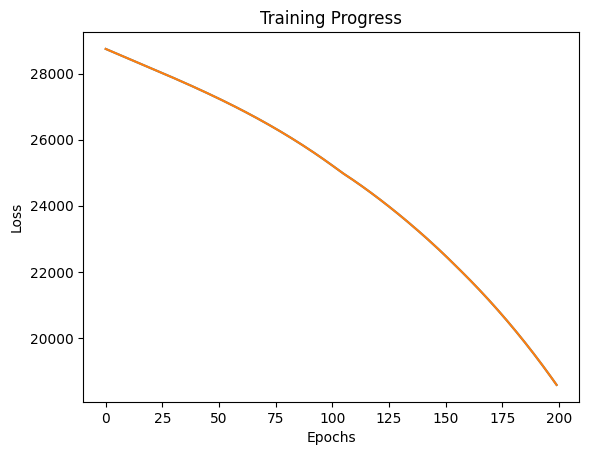

In [73]:
plt.plot(history.history['loss'],label='Loss (MSE)')
plt.plot(history.history['mae'],label='Mean Absolute Error')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.show()

In [74]:
test_sample = np.array([[160,3550,2.5]])
prediction = model.predict(test_sample)
print('Prediction Price: ',prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Prediction Price:  9496.997
